In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.monte_carlo import run_simulation

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def B0_from_HF0(S0, Q, LT, HF0):
    return (Q * S0 * LT) / HF0

In [3]:
base_params = dict(
    S0=100.0,
    mu=0.0,
    sigma=0.4,
    T=1.0,
    N=252,
    n_paths=5000,

    Q=1.0,          # ✅ collateral quantity
    LT=0.8,         # ✅ liquidation threshold

    B0=None,        # will be set from HF0
    r_b=0.0
)


In [4]:
print(base_params.keys)

<built-in method keys of dict object at 0x000001D46D05E200>


In [5]:
def run_scenario(params, HF0):
    params = params.copy()

    params["B0"] = B0_from_HF0(
        params["S0"],
        params["Q"],
        params["LT"],
        HF0
    )

    return run_simulation(params)



Baseline liquidation prob: 0.1826
Stress liquidation prob: 0.7022


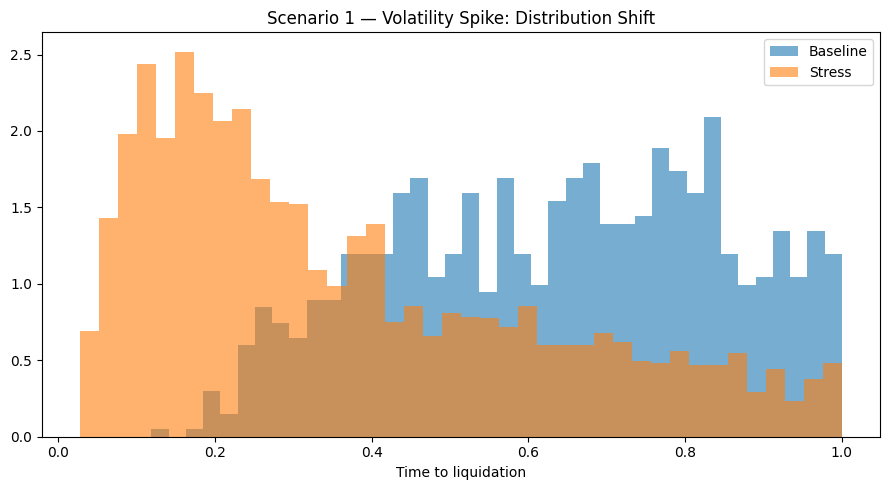

In [6]:
HF0 = 1.8

# Baseline
params_base = base_params.copy()
params_base["sigma"] = 0.4
res_base = run_scenario(params_base, HF0)

# Stress
params_stress = base_params.copy()
params_stress["sigma"] = 1.0
res_stress = run_scenario(params_stress, HF0)

print("Baseline liquidation prob:", res_base["liquidation_prob"])
print("Stress liquidation prob:", res_stress["liquidation_prob"])

plt.figure(figsize=(9, 5))
plt.hist(
    res_base["liquidation_times"][res_base["liquidated"]],
    bins=40, density=True, alpha=0.6, label="Baseline"
)
plt.hist(
    res_stress["liquidation_times"][res_stress["liquidated"]],
    bins=40, density=True, alpha=0.6, label="Stress"
)
plt.legend()
plt.xlabel("Time to liquidation")
plt.title("Scenario 1 — Volatility Spike: Distribution Shift")
plt.tight_layout()
plt.show()



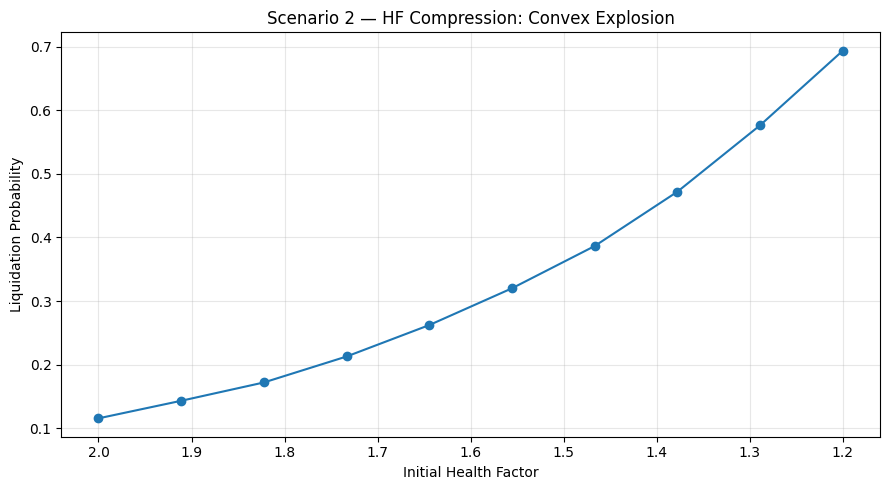

In [7]:
HF0_grid = np.linspace(2.0, 1.2, 10)
liq_probs = []

for HF0 in HF0_grid:
    params = base_params.copy()
    params["sigma"] = 0.4
    res = run_scenario(params, HF0)
    liq_probs.append(res["liquidation_prob"])

liq_probs = np.array(liq_probs)

plt.figure(figsize=(9, 5))
plt.plot(HF0_grid, liq_probs, marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Initial Health Factor")
plt.ylabel("Liquidation Probability")
plt.title("Scenario 2 — HF Compression: Convex Explosion")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
HF0 = 1.3

params_ref = base_params.copy()
params_ref["sigma"] = 0.4
res_ref = run_scenario(params_ref, HF0)

params_combo = base_params.copy()
params_combo["sigma"] = 0.8
res_combo = run_scenario(params_combo, HF0)

print("Baseline prob:", res_ref["liquidation_prob"])
print("Combined stress prob:", res_combo["liquidation_prob"])

Baseline prob: 0.5602
Combined stress prob: 0.8188


In [ ]:
HF0_grid = np.linspace(2.0, 1.2, 9)     # leverage axis
sigma_grid = np.linspace(0.2, 1.0, 9)   # volatility axis

liq_surface = np.zeros((len(sigma_grid), len(HF0_grid)))

for i, sigma in enumerate(sigma_grid):
    for j, HF0 in enumerate(HF0_grid):
        params = base_params.copy()
        params["sigma"] = sigma

        res = run_scenario(params, HF0)
        liq_surface[i, j] = res["liquidation_prob"]

plt.figure(figsize=(9, 6))

im = plt.imshow(
    liq_surface,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    extent=[
        HF0_grid[0], HF0_grid[-1],
        sigma_grid[0], sigma_grid[-1]
    ]
)

plt.colorbar(im, label="Liquidation Probability")

plt.xlabel("Initial Health Factor (HF₀)")
plt.ylabel("Volatility (σ)")
plt.title("Liquidation Risk Surface: Convexity in (HF₀, σ) Space")

plt.gca().invert_xaxis()  # boundary on the right
plt.tight_layout()
plt.show()
